# M2.Ex1: Advertising Revenue

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M2/exercises/ex1_multi-reg.ipynb)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split

## Advertising Dataset

The Advertising Dataset is a fundamental resource in statistical learning and regression analysis. It is primarily known for its use in the first chapter of the seminal textbook "An Introduction to Statistical Learning" (ISLR) by Gareth James, Daniela Witten, Trevor Hastie, and Robert Tibshirani.

The dataset is used to illustrate the relationship between advertising budgets across different media and the resulting product sales.

- Features: `3` numerical
- Target: `sales` of the product (in thousands of units).
- Size: `200` samples.
- Source: [Advertising Dataset](https://www.statlearning.com/s/Advertising.csv)

### Step 1. Load the data

In [2]:
df = pd.read_csv("/content/Advertising.csv")
df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


### Step 2.a Assign variables `X` to the features and `y` to the target

In [3]:
X = df[["TV", "radio", "newspaper"]]      # features
y = df["sales"]                           # target

### Step 2.b print the type of each

In [4]:
X.dtypes

,0
TV,float64
radio,float64
newspaper,float64


In [5]:
y.dtypes

dtype('float64')

### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

* Target is: numerical (sales)
* Task is: regression

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [6]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (200, 3)
y shape: (200,)


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [7]:
df.describe()

,Unnamed: 0,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


### Step 5. How much difference do you see in the scale of each feature? (calculate the featre-wise range differences)

* NOTE: feature‑wise range differences: means to compare how much each feature varies by calculating its range, and we do each feature separately that is why we called it feature wise. (Range = max value − min value)



In [8]:
feature_wise_range = X.max() - X.min()
feature_wise_range

,0
TV,295.7
radio,49.6
newspaper,113.7


* The features are on very different scales: TV varies the most (295.7), radio the least (49.6), and newspaper is in between (113.7). Because these scale differences are large, applying feature scaling is important before modeling.

### Step 6.a Plot each of the features vs the target

Hint use this: `sns.pairplot()`

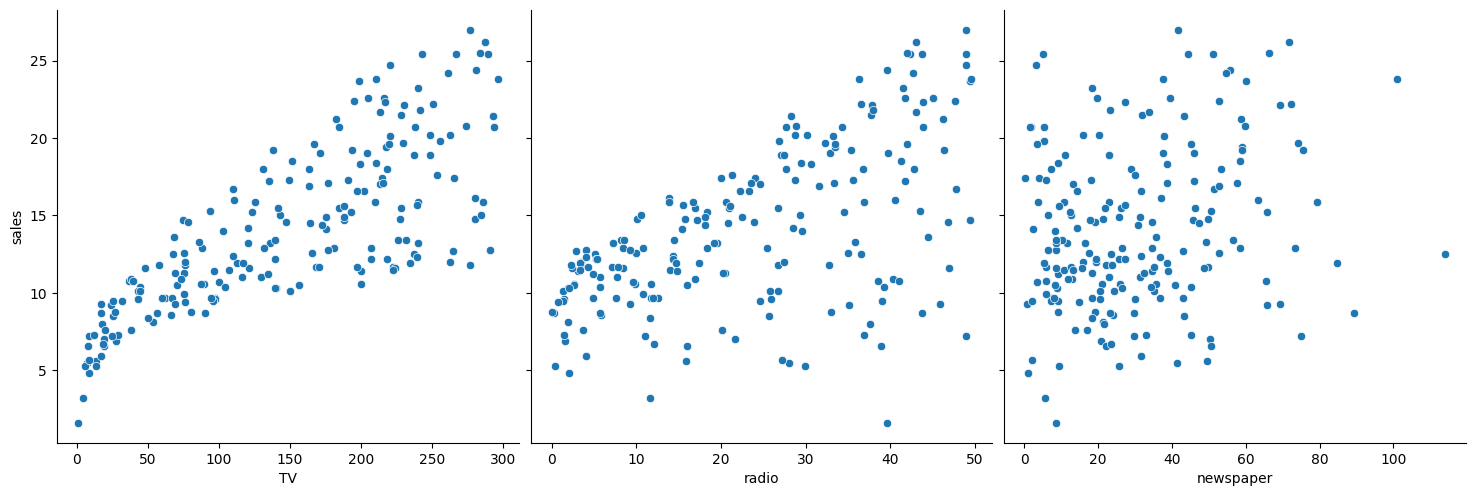

In [9]:
sns.pairplot(df, x_vars=["TV", "radio", "newspaper"], y_vars="sales" , height = 5)
plt.show()

### Step 6.b What is the relationship between the feature and the target? (increasing or decreasing or none)

1. `x=TV` and `y=Sales`
2. `x=Radio` and `y=Sales`
3. `x=Newspaper` and `y=Sales`

**Answer:**

1. x = TV and y = Sales:

* TV shows a strong increasing relationship with sales. As TV spending increases, sales also increase, and the points form a linear trend.

2. x = Radio and y = Sales:

* Radio shows a moderate increasing relationship with sales. As radio spending increases, sales generally increase as well, but the points are more scattered, indicating a weaker pattern than TV.

3. x = Newspaper and y = Sales:

* Newspaper shows a weak or no meaningful relationship with sales. The points are widely scattered with no strong visible trend, suggesting little to no relationship.

### Step 7. Define the pipeline with pre-processing steps

Make a Pipeline of three sequential steps:

1. transformer: `SimpleImputer` (to fill in missing values)
2. transformer: `StandardScaler` (to scale numerical features)
3. predictor: `LinearRegression` (to model the relationship)

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [11]:
preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler())
    ]
)

predictor = LinearRegression()

In [12]:
pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", predictor),
    ]
)

### Step 8. Split the dataset into train and test sets

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

### Step 9.a Fit the pipeline on the training set

In [14]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('imputer', SimpleImputer()),
                                 ('scaler', StandardScaler())])),
                ('regressor', LinearRegression())])

### Step 9.b Identify the learned coefficients (for each feature) and the bias term

In [15]:
model = pipe.named_steps["regressor"]

print("Coefficients are:", model.coef_)
print("Bias term (Intercept) is:", model.intercept_)

Coefficients are: [3.76419618 2.79230665 0.05597551]
Bias term (Intercept) is: 14.100000000000001


### Step 9.c how much spending on TV `$1,000` more, factor into Sales?

* TV coefficient = 3.764. Since Sales are measured in thousands of units, this means: For every additional $1,000 spent on TV advertising, sales increase by about 3.764 thousand units (3.764 × 1000 = 3,764 units).

In [16]:
# $1,000 = 1 unit

TV_spend = model.coef_[0] * 1
print("Spending $1,000 more on TV, increases Sales by" , round(TV_spend,2) , " thousand units")

Spending $1,000 more on TV, increases Sales by 3.76  thousand units


### Step 9.d if we take `$5,000` away from Newspaper and put it in Radio how much difference does that make into Sales?

NOTE:

Newspaper coefficient ≈ 0.055.
Newspaper decreases by 5 units. =  0.055 x 5 = 0.275

Radio coefficient ≈ 2.792.
Radio increases by 5 units. =  2.792 x 5 = 13.96

Net sales: 13.96 − 0.275  = 13.685

Moving $5,000 from Newspaper to Radio increases sales by about 13.68 thousand units.

In [17]:
# $5,000 = 5 unit

net_sale = - (model.coef_[2] * 5) + (model.coef_[1] * 5)
print("Moving $5,000 from Newspaper to Radio increases sales by" , round(net_sale,2) , "thousand units")

Moving $5,000 from Newspaper to Radio increases sales by 13.68 thousand units


### Step 9.e if we spend nothing at all on advertising, how much do we estimate our Sales to be?

In [18]:
print("if we spend nothing at all on advertising the estimated sales is:" , round(model.intercept_,2) , "thousand units")

if we spend nothing at all on advertising the estimated sales is: 14.1 thousand units


### Step 10. Evaluate the pipeline on the test set

In [19]:
score = pipe.score(X_test, y_test)
score

0.8994380241009119

### Step 11. Define a `LinearRegression` model without the pre-processing steps, and compare it's score with the pipeline. Which one is better?

In [20]:
model_without_pipe = LinearRegression()

model_without_pipe.fit(X_train, y_train)

score_no_pipe = model_without_pipe.score(X_test, y_test)

In [21]:
# To compare with the score:

print("Pipeline score is:", score)
print("No pre-processing steps score is:", score_no_pipe)

Pipeline score is: 0.8994380241009119
No pre-processing steps score is: 0.899438024100912


* Both models achieve the same score (= 0.899), so the pipeline and the no‑preprocessing linear regression model perform equally well on this dataset. Therefore, neither model is better in terms of performance.
